# Phase 2 — Calibration & Backtesting

Run Phase 1 (1 month, heuristic params) → calibrate from data → run Phase 2 (1 month, calibrated params) → compare P&L.

In [1]:
import sys, copy, time
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append('../src')

import utils.stock_simulation as stock_mod
import utils.market_simulator as market_mod
import utils.order_book.order_book_impl as book_mod
import utils.market_maker.quoter as quoter_mod
import utils.report.pnl_tracker as pnl_mod
import utils.report.controller as ctrl_mod
import utils.client_flow.flow_generator as flow_mod
import utils.calibration as cal_mod
import utils.report.fast_config as fast_cfg_mod

for mod in [stock_mod, market_mod, book_mod, quoter_mod,
            pnl_mod, ctrl_mod, flow_mod, cal_mod, fast_cfg_mod]:
    importlib.reload(mod)

from utils.stock_simulation import Stock
from utils.market_simulator.market import Market
from utils.order_book.order_book_impl import Order_book
from utils.market_maker.quoter import Quoter, QuoterConfig
from utils.report.controller import Controller
from utils.client_flow.flow_generator import ClientFlowGenerator
from utils.calibration import CalibratedConfigBuilder
from utils.report import fast_config

SEED = 42
CAPITAL = 1_000_000.0
N_DAYS = 5
DT_SECONDS = 0.05   # 0.05 s steps — matches Phase 1 resolution

print('All modules loaded.')

All modules loaded.


---
## Phase 1 — Heuristic Parameters

1-month backtest with default `QuoterConfig` and `ClientFlowConfig`.

In [2]:
from utils.simulation.session import save_markets, load_markets
import pathlib

_P1_CACHE = pathlib.Path('../src/utils/simulation/phase1_markets.pkl')

if _P1_CACHE.exists():
    stock_p1, mkt_B1, mkt_C1 = load_markets(_P1_CACHE)
    print(f'Phase 1 markets loaded from cache ({stock_p1.n_steps} steps)')
else:
    np.random.seed(SEED)
    stock_p1 = Stock(drift=0.0, vol=0.07, origin=1.10)
    stock_p1.simulate_garch(n_days=N_DAYS, dt_seconds=DT_SECONDS,
                            alpha=0.05, beta=0.94,
                            lam=100,       # 100 jumps/year ≈ 2/week
                            sigma_J=0.005) # ±0.5% per jump std ≈ 55 pips on EUR/USD

    mkt_B1, mkt_C1 = fast_config.build_markets_B_C(stock_p1)

    save_markets(stock_p1, mkt_B1, mkt_C1, _P1_CACHE)
    print(f'Phase 1 markets generated and cached ({stock_p1.n_steps} steps)')

print(f'Phase 1 stock: {stock_p1.n_steps} steps, dt = {stock_p1.time_step:.3f} s')

Loading markets from ..\src\utils\simulation\phase1_markets.pkl...
Markets loaded ← ..\src\utils\simulation\phase1_markets.pkl
Phase 1 markets loaded from cache (8640000 steps)
Phase 1 stock: 8640000 steps, dt = 0.050 s


In [3]:
# Quoter + order book + client flow (all defaults)
cfg_p1 = QuoterConfig()
book_p1 = Order_book()
mm_p1 = Quoter(mkt_B1, mkt_C1, config=cfg_p1, capital_K=CAPITAL)
book_p1.register_quoter_listener(mm_p1.on_fill)

gen_p1 = ClientFlowGenerator(seed=SEED)
client_flow_fn_p1 = lambda step, t, mid, bid, ask, dt: \
    gen_p1.generate_step(mid_price=mid, best_bid=bid, best_ask=ask, dt=dt)

ctrl_p1 = Controller(mkt_B1, mkt_C1, book_p1, mm_p1, client_flow_fn_p1)
print('Phase 1 controller ready.')

Phase 1 controller ready.


In [4]:
# Run Phase 1
t0 = time.time()
ctrl_p1.simulate()
elapsed = time.time() - t0

df_p1 = ctrl_p1.trade_history
mm_fills_p1 = df_p1[~df_p1['is_hedge']]
hedges_p1 = df_p1[df_p1['is_hedge']]

print(f'Phase 1 done in {elapsed:.1f} s')
print(f'MM fills: {len(mm_fills_p1)}  |  Hedge legs: {len(hedges_p1)}')
print(f'Fills per day: {len(mm_fills_p1) / N_DAYS:.1f}')
print(f'Final inventory: {ctrl_p1.quoter.inventory:,.0f} EUR')

  0%|          | 0/8640000 [00:00<?, ?it/s]

100%|██████████| 8640000/8640000 [08:16<00:00, 17412.93it/s]

Phase 1 done in 496.2 s
MM fills: 2315  |  Hedge legs: 0
Fills per day: 463.0
Final inventory: 205,018 EUR


════════════════════════════════════════════════════════════════════
  BACKTESTING REPORT — Phase 1   (5.0 days, dt=0.1s, 8,640,000 steps)
════════════════════════════════════════════════════════════════════
  Total MtM P&L                               -92.36  USD
    Realized cash P&L                     -225367.02  USD
    Unrealized (open inventory × mid)      +225274.67  USD
────────────────────────────────────────────────────────────────────
  Inception spread P&L                      +2038.54  USD
    (spread captured at fill time)  
  Inventory revaluation P&L                 -1396.05  USD
    (mid drift on open EUR position)
  Total fees paid                             734.84  USD
    Maker fees (exchange A)                   734.84  USD
    Taker fees (hedge B/C)                      0.00  USD
────────────────────────────────────────────────────────────────────
  MM fills                                     2,315  (463/day)
  Hedge legs                                       

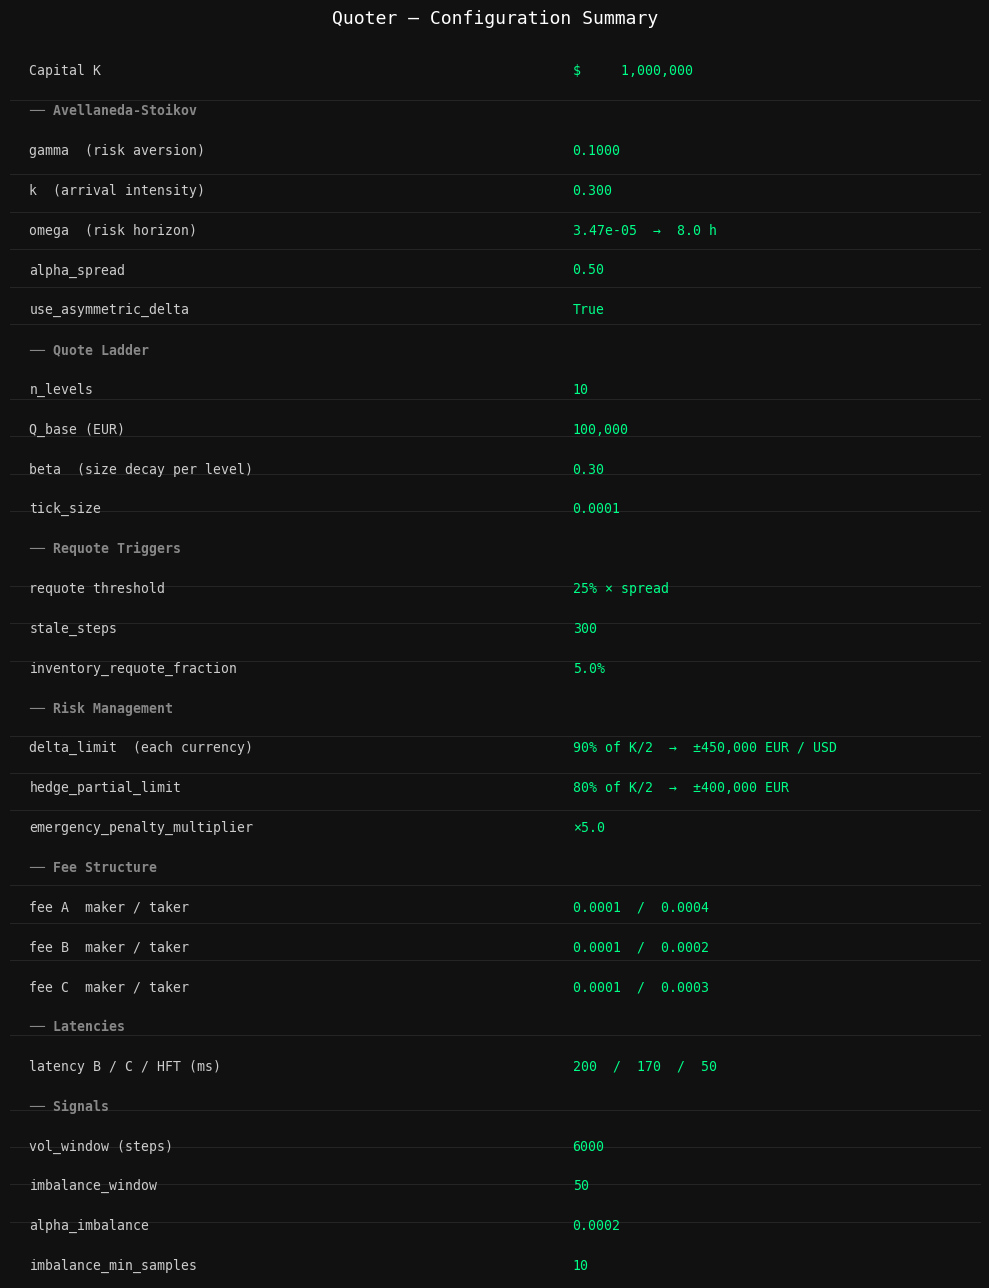

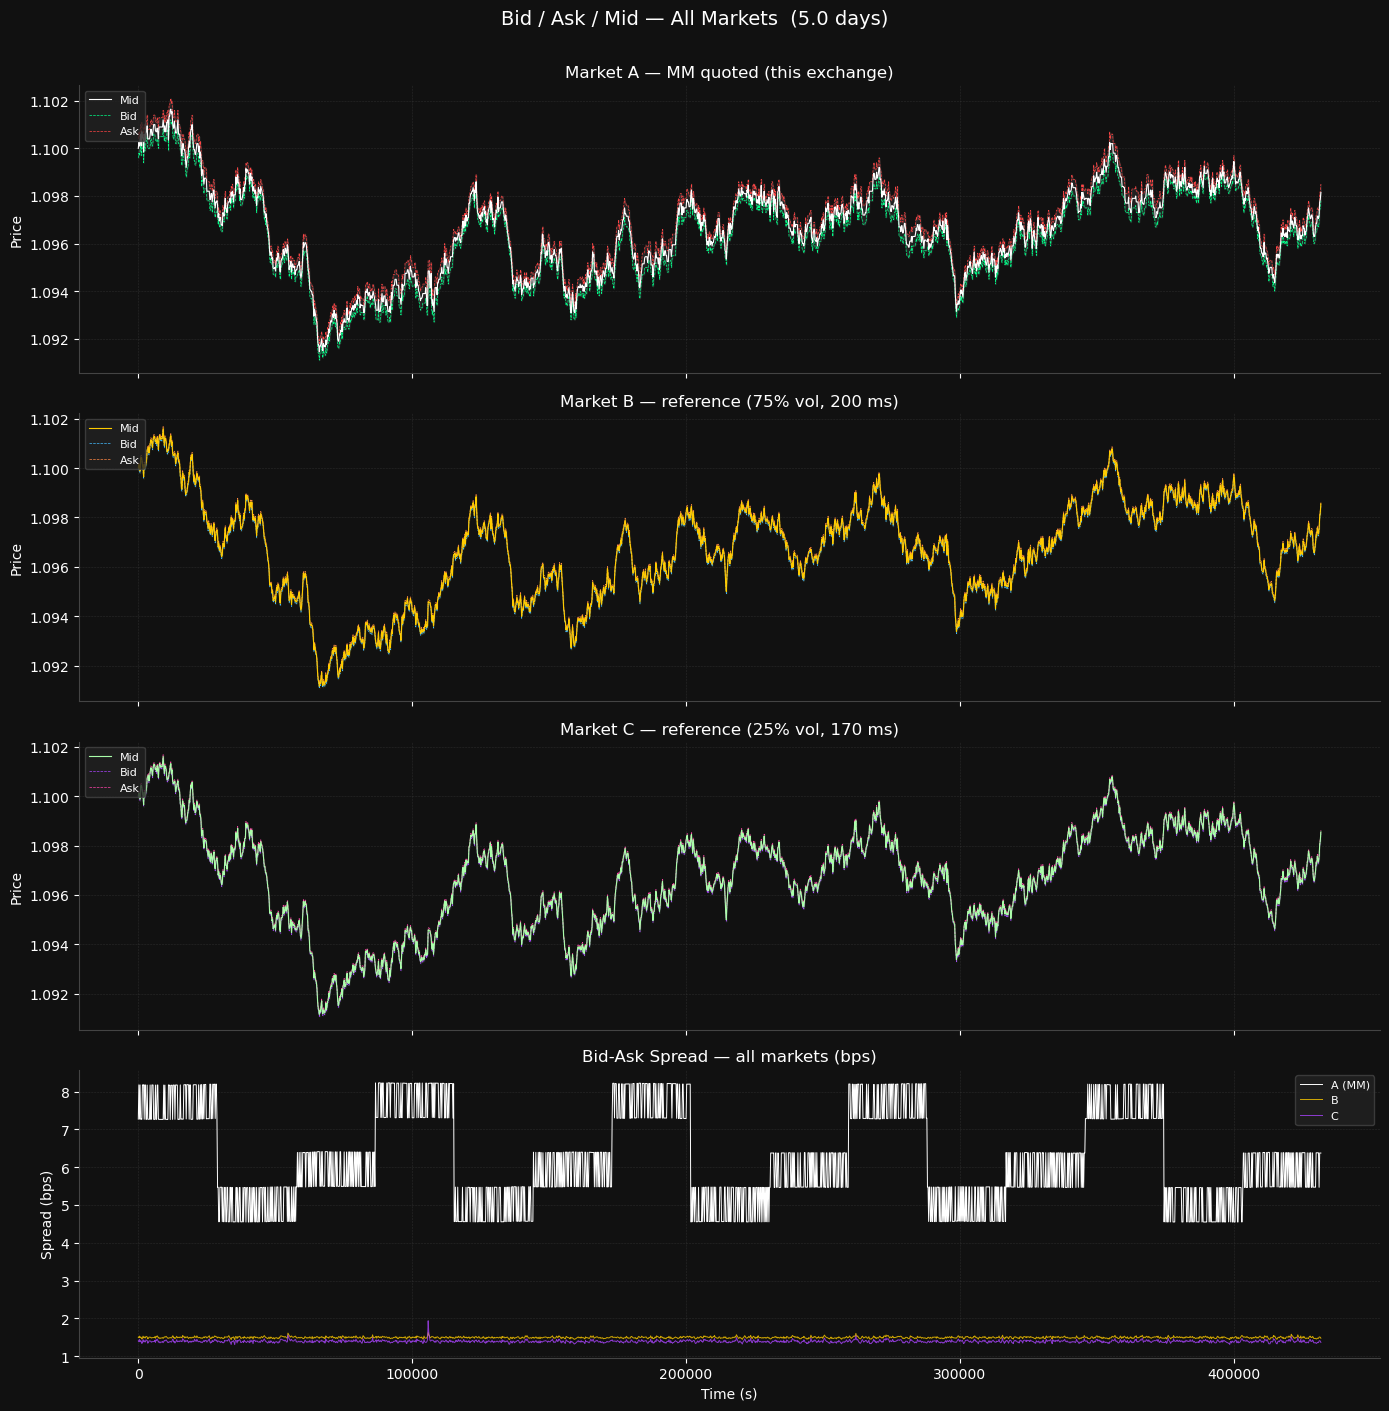

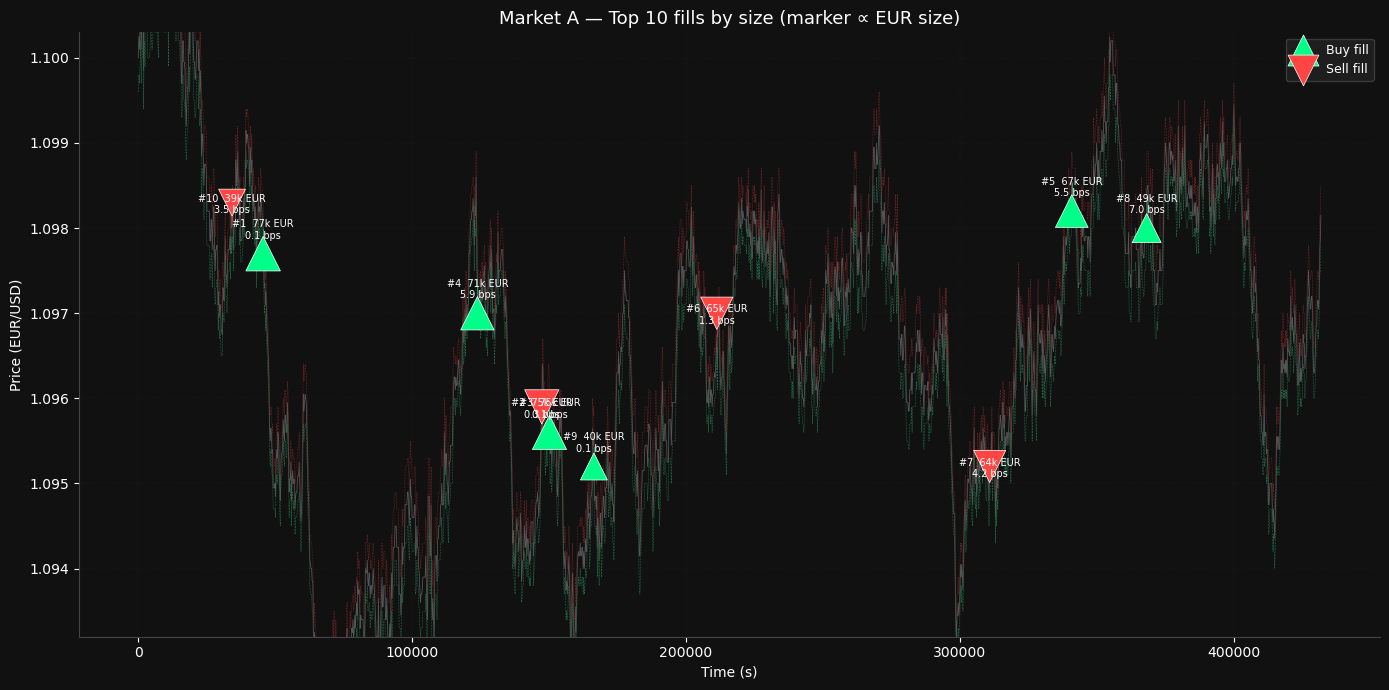

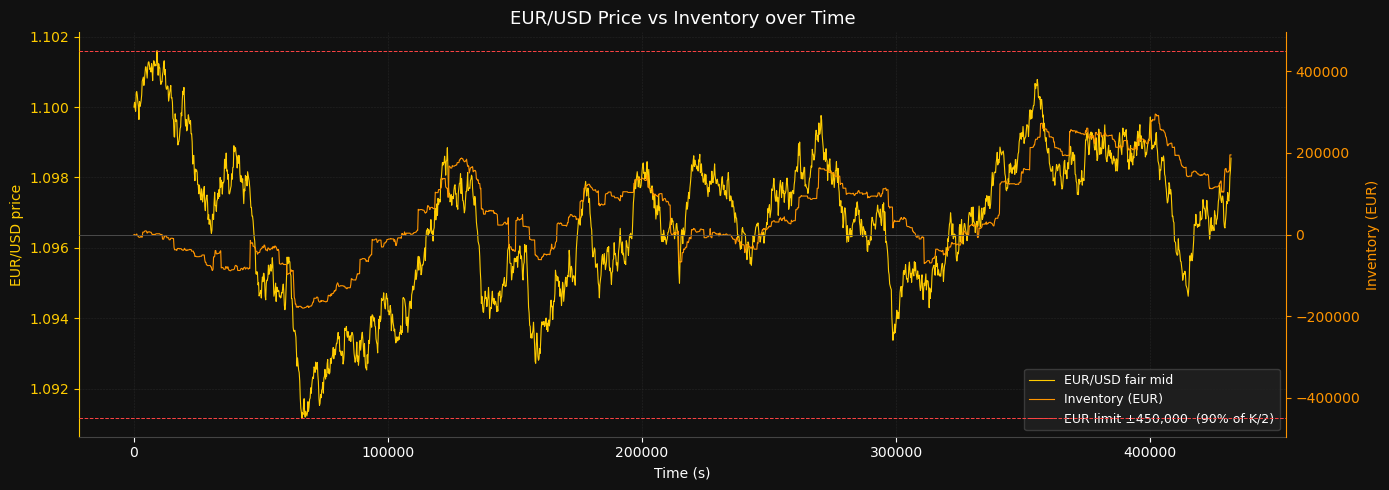

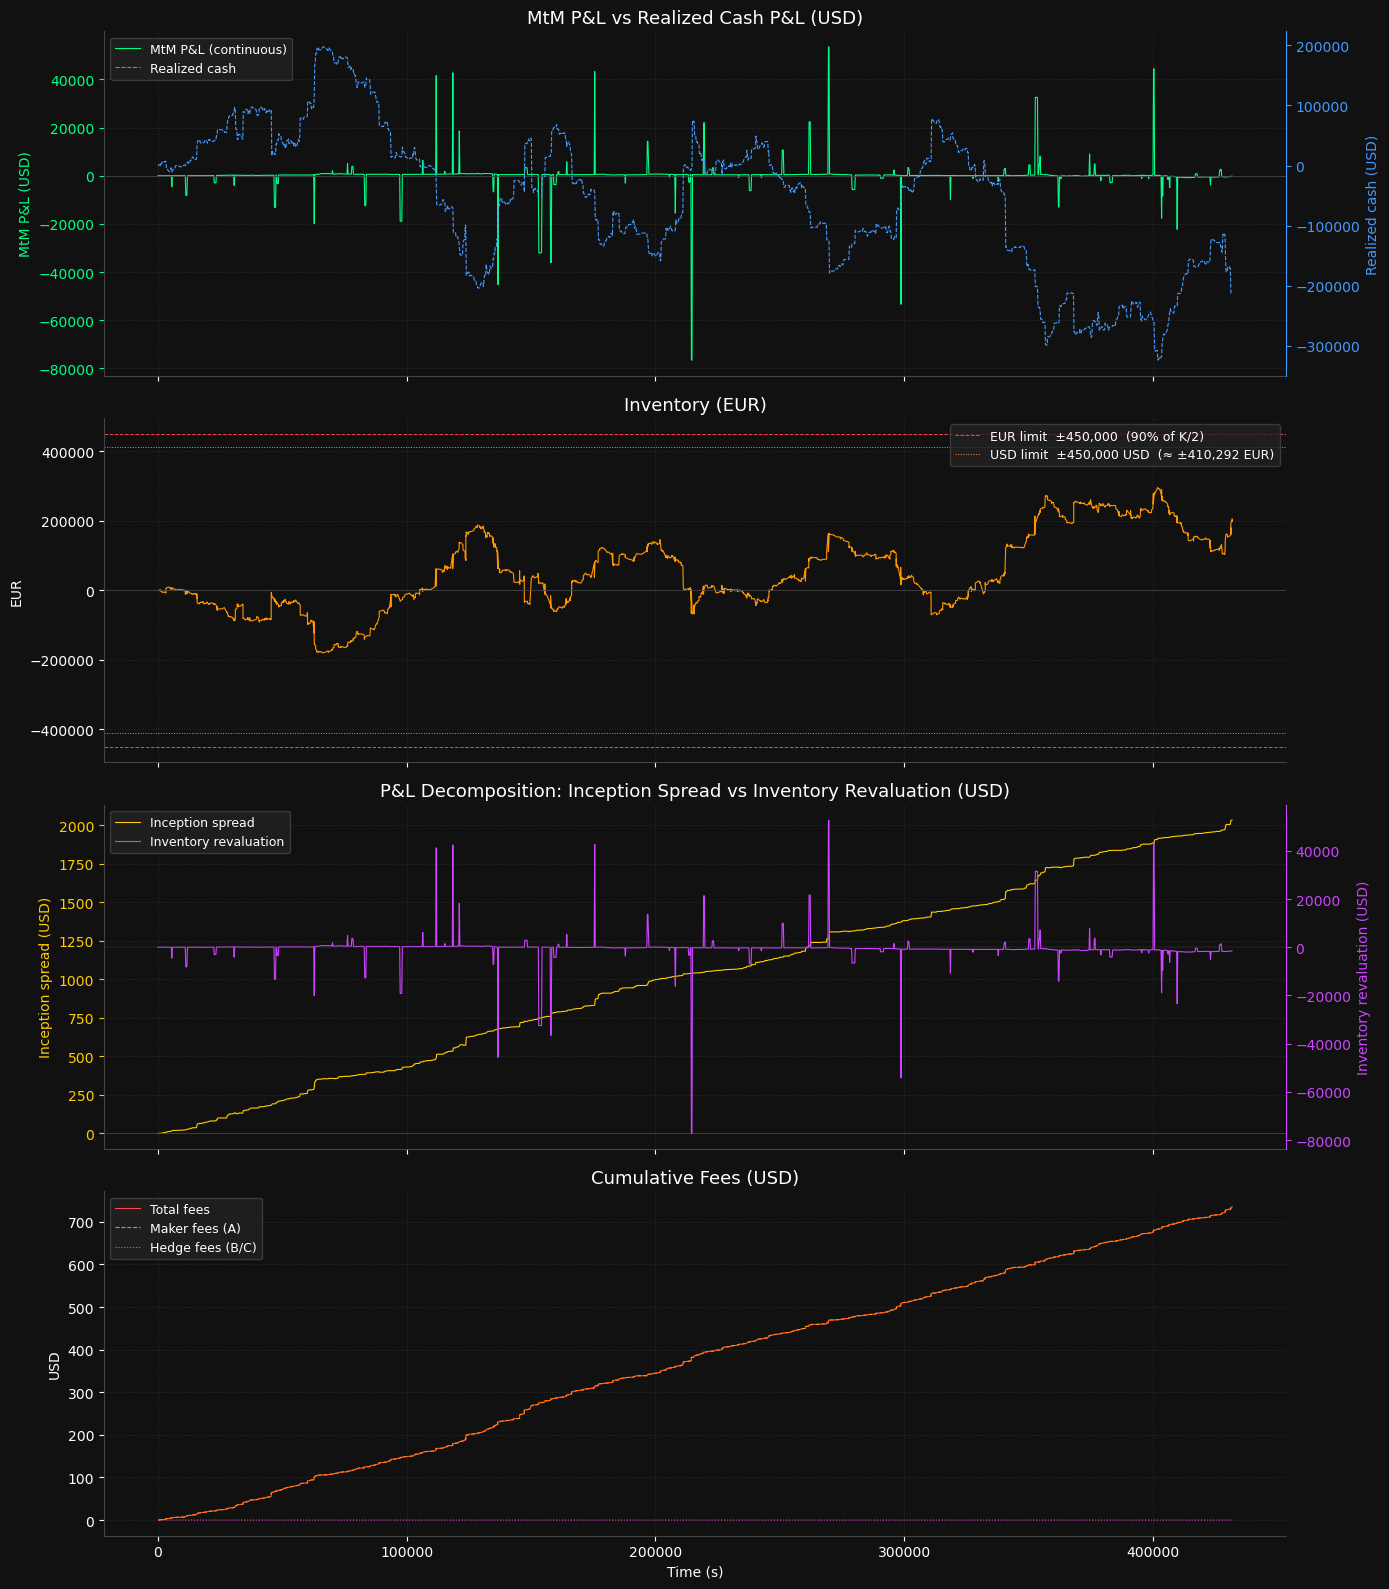

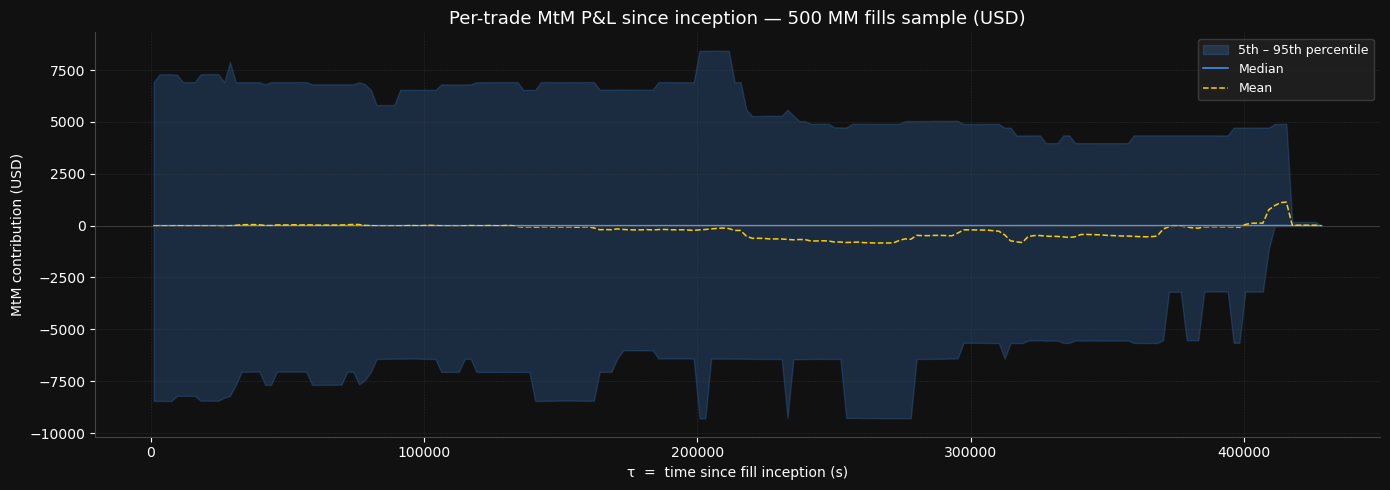

────────────────────────────────────────────────────────────────────
  FILL-RATE ANALYSIS
────────────────────────────────────────────────────────────────────
  MM fills                                     2,315
  Quotes posted                              112,377
  Overall fill rate                          2.0600%
  Avg fill size (EUR)                          2,895
  Full fills                                    0.2%
  Partial fills                                99.8%
────────────────────────────────────────────────────────────────────
  Level         Fill count   Relative rate
  1                  2,315           1.000
════════════════════════════════════════════════════════════════════


In [5]:
# Phase 1 report
ctrl_p1.report()

---
## Calibration

Use Phase 1 data to estimate model parameters via MLE / regression / grid search.

In [6]:
builder = CalibratedConfigBuilder(ctrl_p1)
quoter_cfg_p2 = builder.build()
print(builder.summary())

  CALIBRATION SUMMARY — Phase 1 → Phase 2  (QuoterConfig only)

  Parameter                      Default   Calibrated
  ------------------------- ------------ ------------
  gamma                              0.1   0.00800556
  omega                         3.47e-05  1.15741e-05
  vol_window                        6000          500
  alpha_spread                       0.5     0.663643
  alpha_imbalance                 0.0002  0.000144229

  Expected daily Sharpe: 556.104
  Vol model recommendation: garch


---
## Phase 2 — Calibrated Parameters

Fresh 1-month price path, capital reset to K, using calibrated configs.

In [ ]:
np.random.seed(SEED)   # Same price path for test

stock_p2 = Stock(drift=0.0, vol=0.07, origin=1.10)
stock_p2.simulate_garch(n_days=N_DAYS, dt_seconds=DT_SECONDS,
                        alpha=0.05, beta=0.94,
                        lam=100,       # 100 jumps/year ≈ 2/week
                        sigma_J=0.005) # ±0.5% per jump std ≈ 55 pips on EUR/USD
print(f'Phase 2 stock: {stock_p2.n_steps} steps, dt = {stock_p2.time_step:.3f} s')

mkt_B2, mkt_C2 = fast_config.build_markets_B_C(stock_p2)

Phase 2 stock: 8640000 steps, dt = 0.050 s
Coefficient annualization : 20867.582514512793


In [8]:
# Quoter + order book with CALIBRATED QuoterConfig, SAME client flow
book_p2 = Order_book()
mm_p2 = Quoter(mkt_B2, mkt_C2, config=quoter_cfg_p2, capital_K=CAPITAL)
book_p2.register_quoter_listener(mm_p2.on_fill)

# Reuse the same ClientFlowConfig (default) — client behaviour is exogenous,
# only the quoting strategy changes between Phase 1 and Phase 2.
gen_p2 = ClientFlowGenerator(seed=SEED + 1)
client_flow_fn_p2 = lambda step, t, mid, bid, ask, dt: \
    gen_p2.generate_step(mid_price=mid, best_bid=bid, best_ask=ask, dt=dt)

ctrl_p2 = Controller(mkt_B2, mkt_C2, book_p2, mm_p2, client_flow_fn_p2)
print('Phase 2 controller ready.')
print(f'Calibrated gamma={quoter_cfg_p2.gamma:.4f}, k={quoter_cfg_p2.k:.4f}, '
      f'vol_window={quoter_cfg_p2.vol_window}')

Phase 2 controller ready.
Calibrated gamma=0.0080, k=0.3000, vol_window=500


In [9]:
# Run Phase 2
t0 = time.time()
ctrl_p2.simulate()
elapsed = time.time() - t0

df_p2 = ctrl_p2.trade_history
mm_fills_p2 = df_p2[~df_p2['is_hedge']]
hedges_p2 = df_p2[df_p2['is_hedge']]

print(f'Phase 2 done in {elapsed:.1f} s')
print(f'MM fills: {len(mm_fills_p2)}  |  Hedge legs: {len(hedges_p2)}')
print(f'Fills per day: {len(mm_fills_p2) / N_DAYS:.1f}')
print(f'Final inventory: {ctrl_p2.quoter.inventory:,.0f} EUR')

100%|██████████| 8640000/8640000 [08:06<00:00, 17753.82it/s]

Phase 2 done in 486.7 s
MM fills: 2106  |  Hedge legs: 0
Fills per day: 421.2
Final inventory: 167,178 EUR


════════════════════════════════════════════════════════════════════
  BACKTESTING REPORT — Phase 1   (5.0 days, dt=0.1s, 8,640,000 steps)
════════════════════════════════════════════════════════════════════
  Total MtM P&L                              +202.09  USD
    Realized cash P&L                     -184341.30  USD
    Unrealized (open inventory × mid)      +184543.39  USD
────────────────────────────────────────────────────────────────────
  Inception spread P&L                      +1958.34  USD
    (spread captured at fill time)  
  Inventory revaluation P&L                 -1090.43  USD
    (mid drift on open EUR position)
  Total fees paid                             665.83  USD
    Maker fees (exchange A)                   665.83  USD
    Taker fees (hedge B/C)                      0.00  USD
────────────────────────────────────────────────────────────────────
  MM fills                                     2,106  (421/day)
  Hedge legs                                       

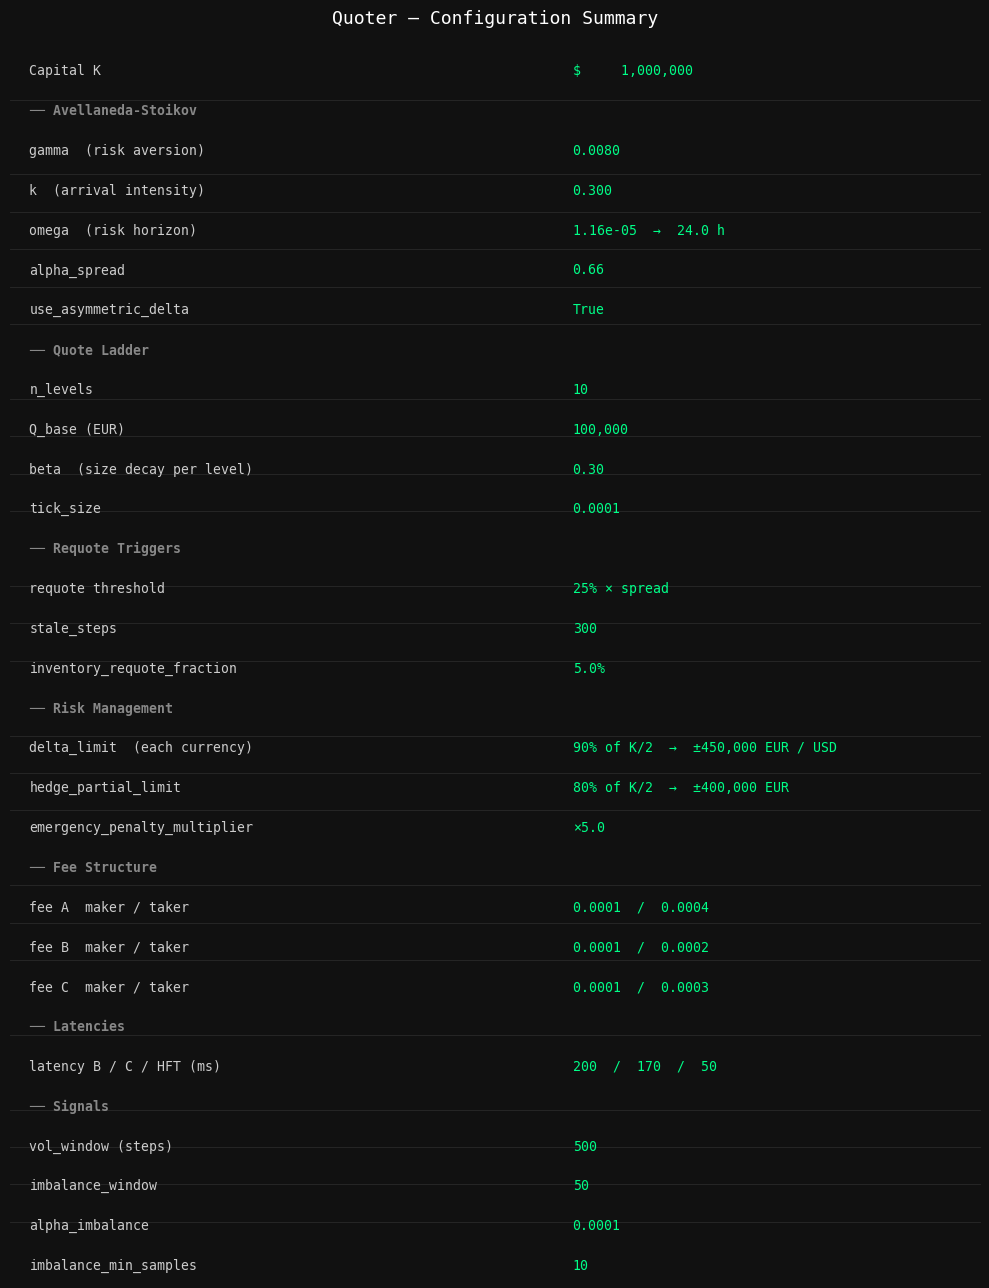

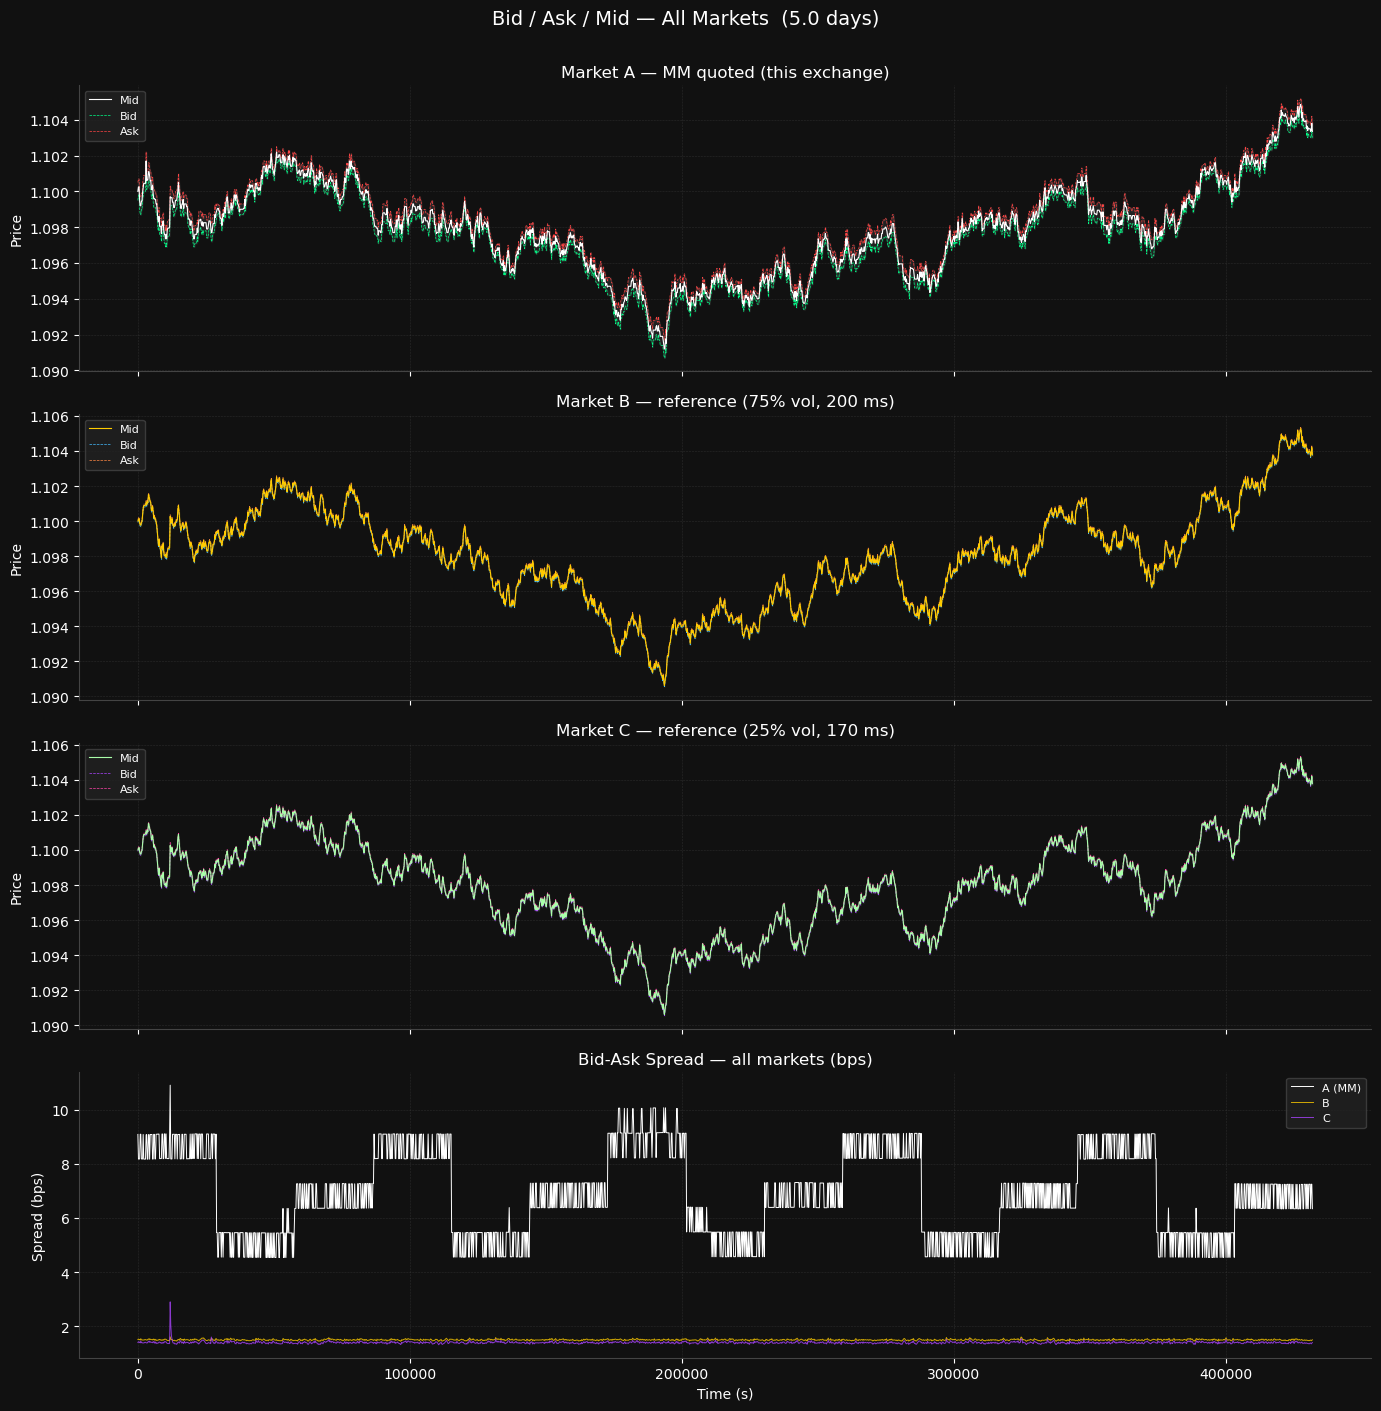

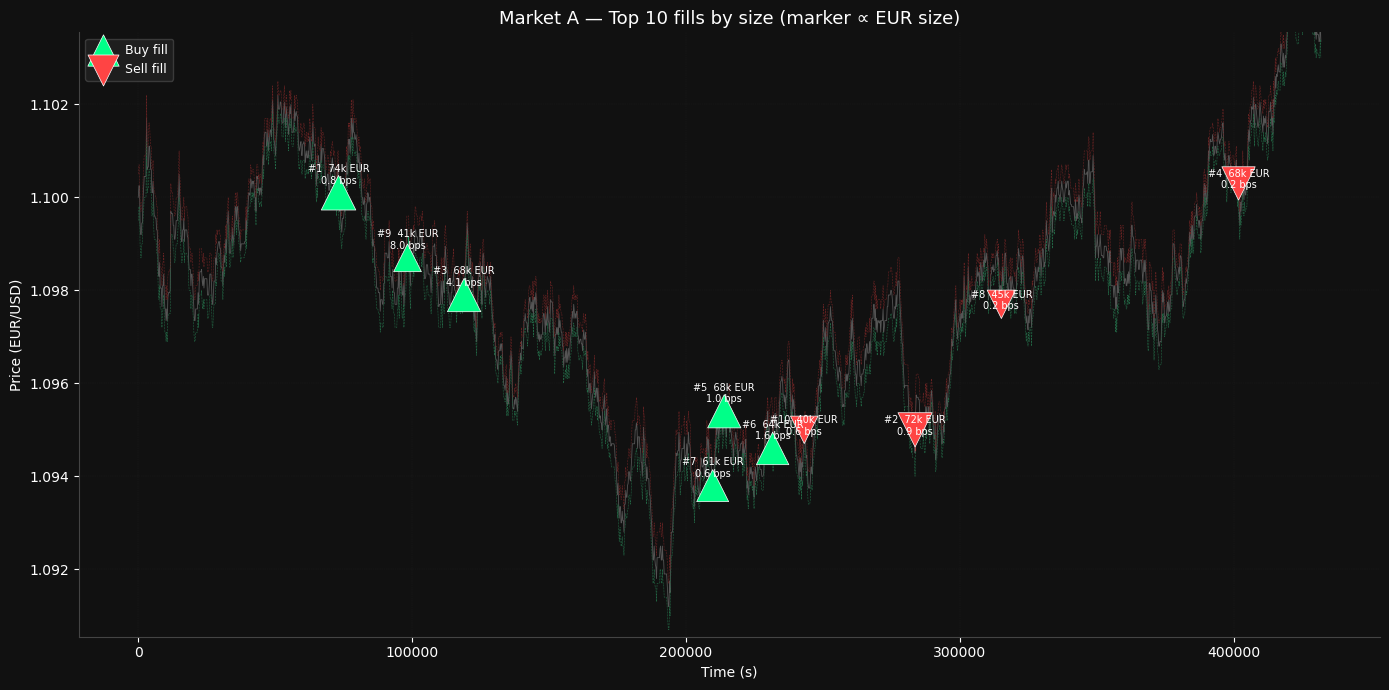

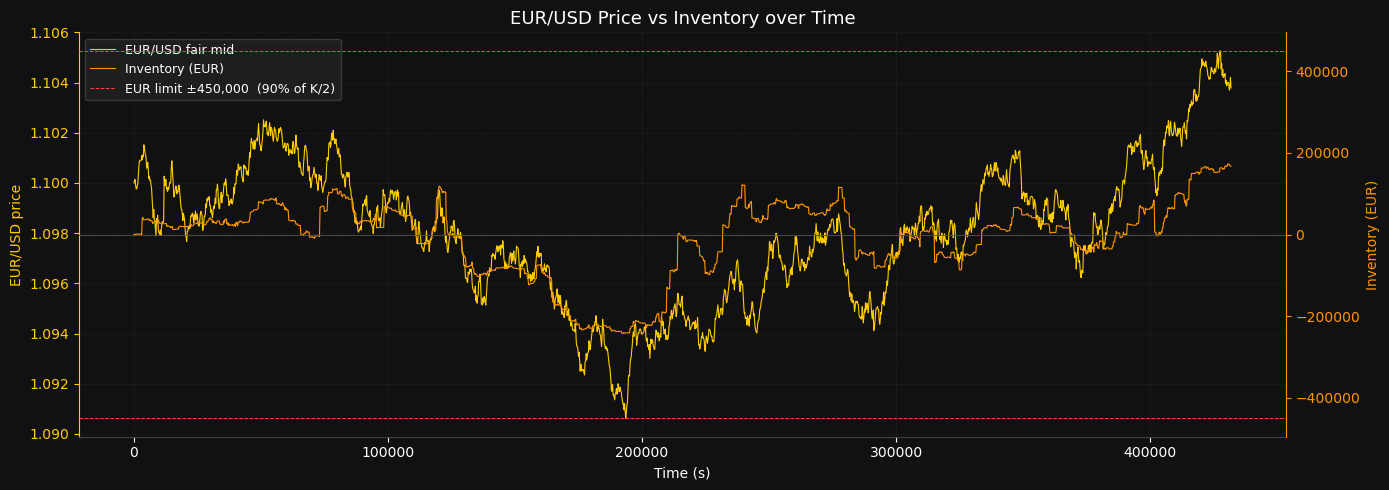

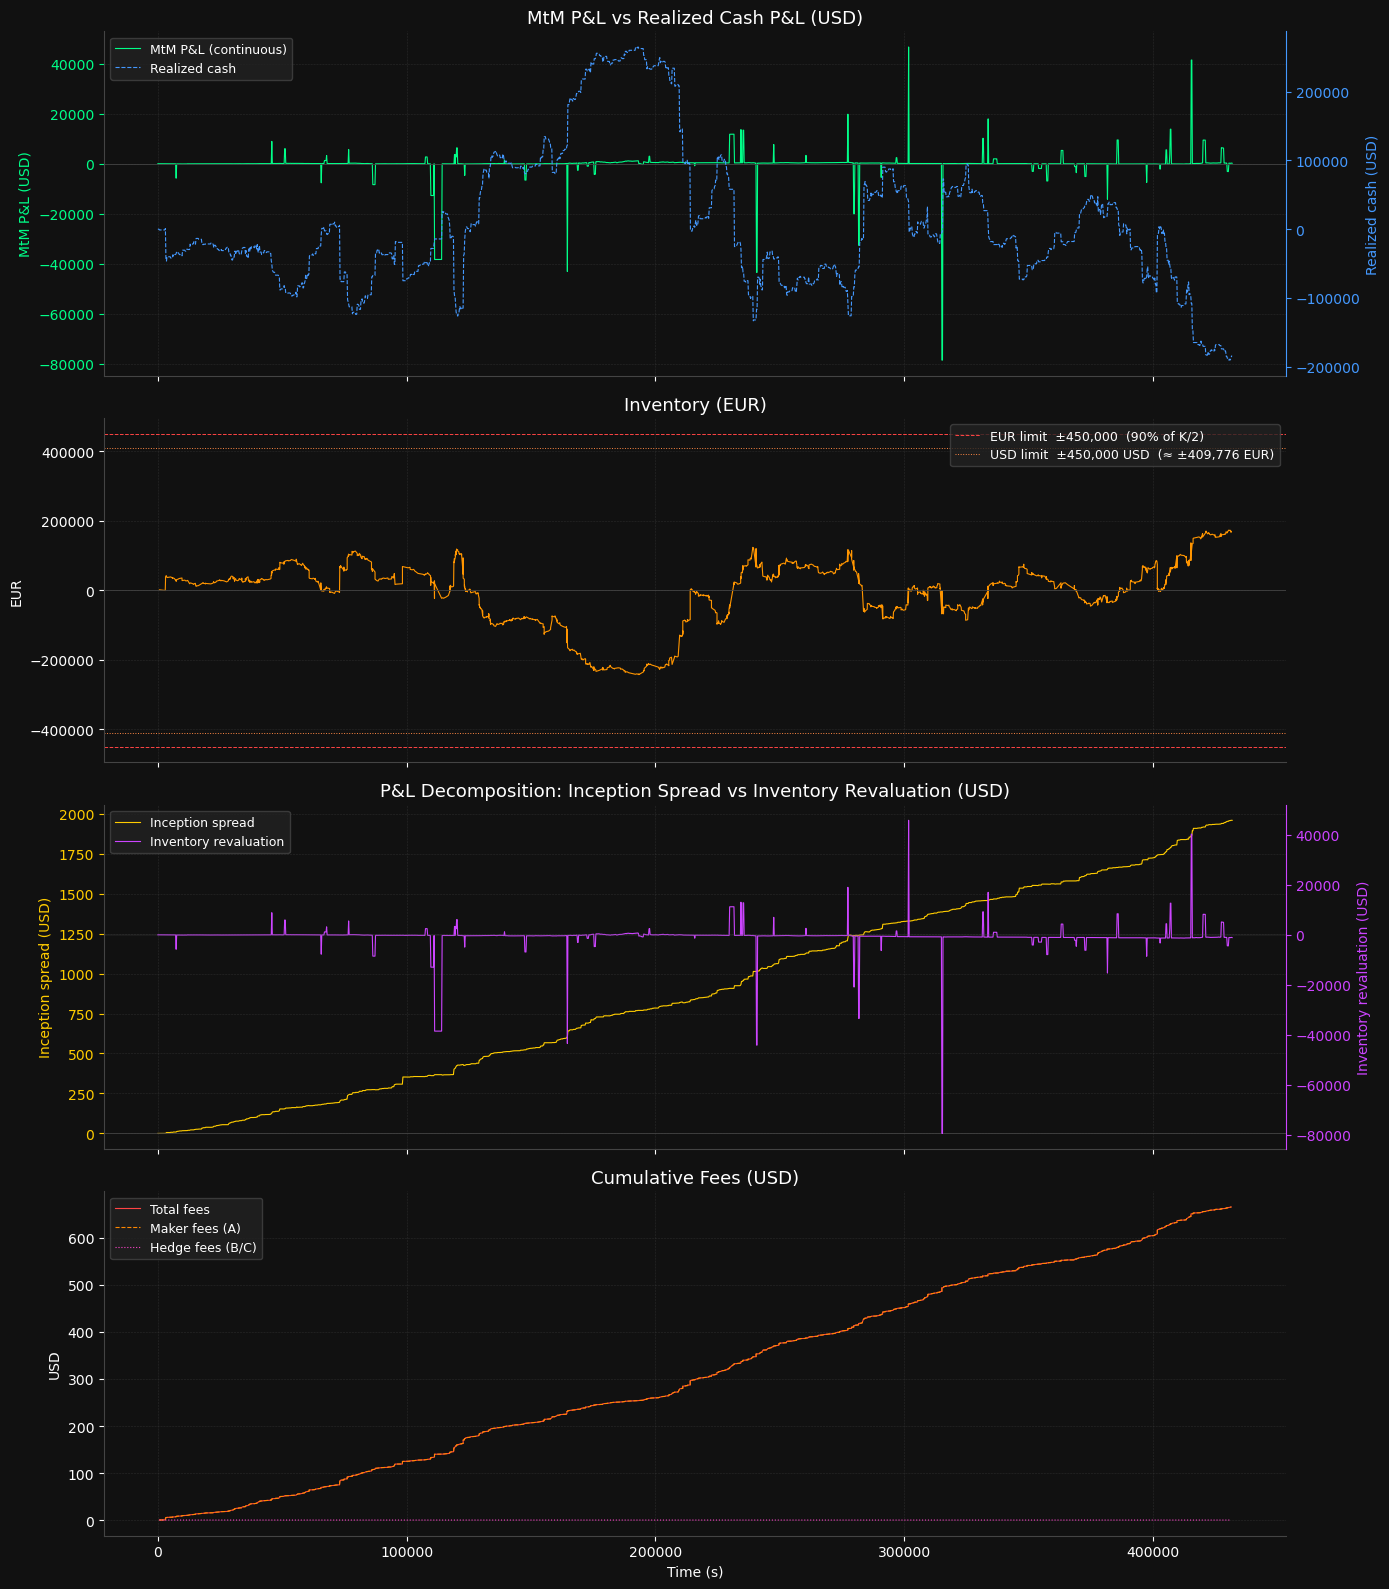

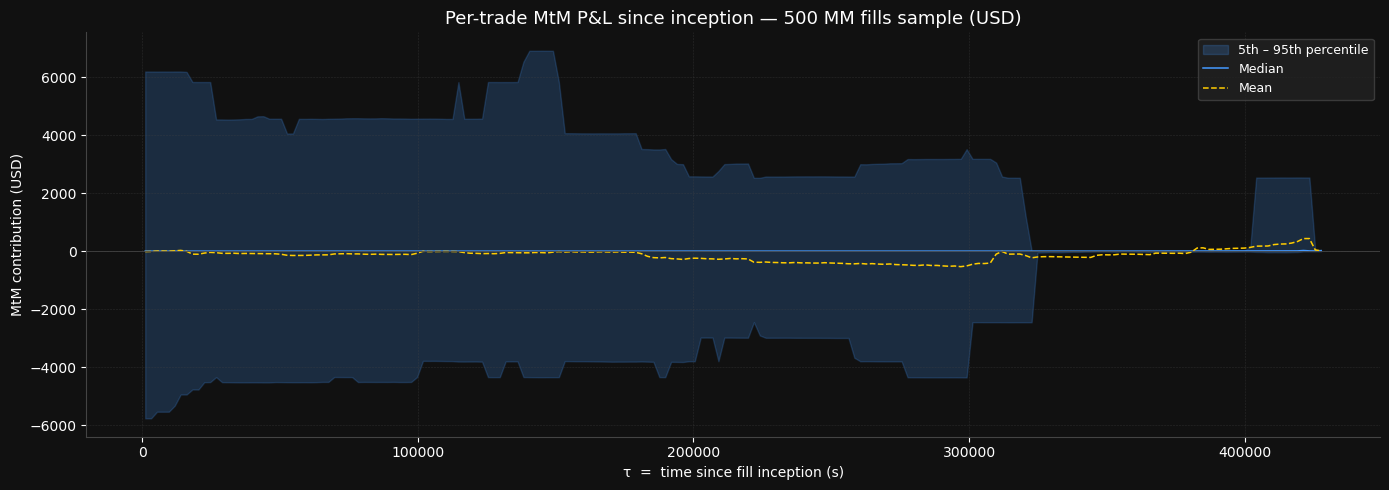

────────────────────────────────────────────────────────────────────
  FILL-RATE ANALYSIS
────────────────────────────────────────────────────────────────────
  MM fills                                     2,106
  Quotes posted                              110,585
  Overall fill rate                          1.9044%
  Avg fill size (EUR)                          2,880
  Full fills                                    0.1%
  Partial fills                                99.9%
────────────────────────────────────────────────────────────────────
  Level         Fill count   Relative rate
  1                  2,104           1.000
  2                      2           0.001
════════════════════════════════════════════════════════════════════


In [10]:
# Phase 2 report
ctrl_p2.report()

---
## Comparison — Phase 1 vs Phase 2

In [11]:
from utils.report.pnl_tracker import PnLTracker

rep_p1 = ctrl_p1.pnl_report()
rep_p2 = ctrl_p2.pnl_report()

print('=' * 64)
print(f'{"Metric":<30} {"Phase 1":>15} {"Phase 2":>15}')
print('-' * 64)
for key, label in [
    ('total_mtm_pnl',           'Total MtM P&L (USD)'),
    ('realized_pnl',            'Realized P&L (USD)'),
    ('unrealized_pnl',          'Unrealized P&L (USD)'),
    ('inception_spread_pnl',    'Inception spread (USD)'),
    ('total_fees',              'Total fees (USD)'),
    ('n_mm_fills',              'MM fills'),
    ('n_hedges',                'Hedge legs'),
    ('final_inventory_eur',     'Final inventory (EUR)'),
]:
    v1 = rep_p1.get(key, 0)
    v2 = rep_p2.get(key, 0)
    if isinstance(v1, int):
        print(f'{label:<30} {v1:>15d} {v2:>15d}')
    else:
        print(f'{label:<30} {v1:>15.2f} {v2:>15.2f}')
print('=' * 64)

Metric                                 Phase 1         Phase 2
----------------------------------------------------------------
Total MtM P&L (USD)                     -92.36          202.09
Realized P&L (USD)                  -225367.02      -184341.30
Unrealized P&L (USD)                 225274.67       184543.39
Inception spread (USD)                 2038.54         1958.34
Total fees (USD)                        734.84          665.83
MM fills                                  2315            2106
Hedge legs                                   0               0
Final inventory (EUR)                205018.00       167178.00
